C:\Users\veron\AppData\Local\Temp\ipykernel_14192\1228970573.py:15: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Rows: 24497
Questionnaires: ['dass_depression_K10', 'dass_fear_K10', 'dass_stress_K10', 'midas_result_K10', 'gvas_result_K10', 'pgic_result_K10', 'chiq_result_K10', 'dass_depression_K11', 'dass_fear_K11', 'dass_stress_K11', 'midas_result_K11', 'gvas_result_K11', 'pgic_result_K11', 'chiq_result_K11', 'dass_depression_K12', 'dass_fear_K12', 'dass_stress_K12', 'midas_result_K12', 'gvas_result_K12', 'pgic_result_K12', 'chiq_result_K12', 'dass_depression_K13', 'dass_fear_K13', 'dass_stress_K13', 'midas_result_K13', 'gvas_result_K13', 'pgic_result_K13', 'chiq_result_K13', 'dass_depression_K14', 'dass_fear_K14', 'dass_stress_K14', 'midas_result_K14', 'gvas_result_K14', 'pgic_result_K14', 'chiq_result_K14', 'dass_depression_K15', 'dass_fear_K15', 'dass_stress_K15', 'midas_result_K15', 'gvas_result_K15', 'pgic_result_K15', 'chiq_result_K15', 'dass_depression_K16', 'dass_fear_K16', 'dass_stress_K16', 'midas_result_K16', 'gvas_result_K16', 'pgic_result_K16', 'chiq_result_K16', 'dass_depression_K1

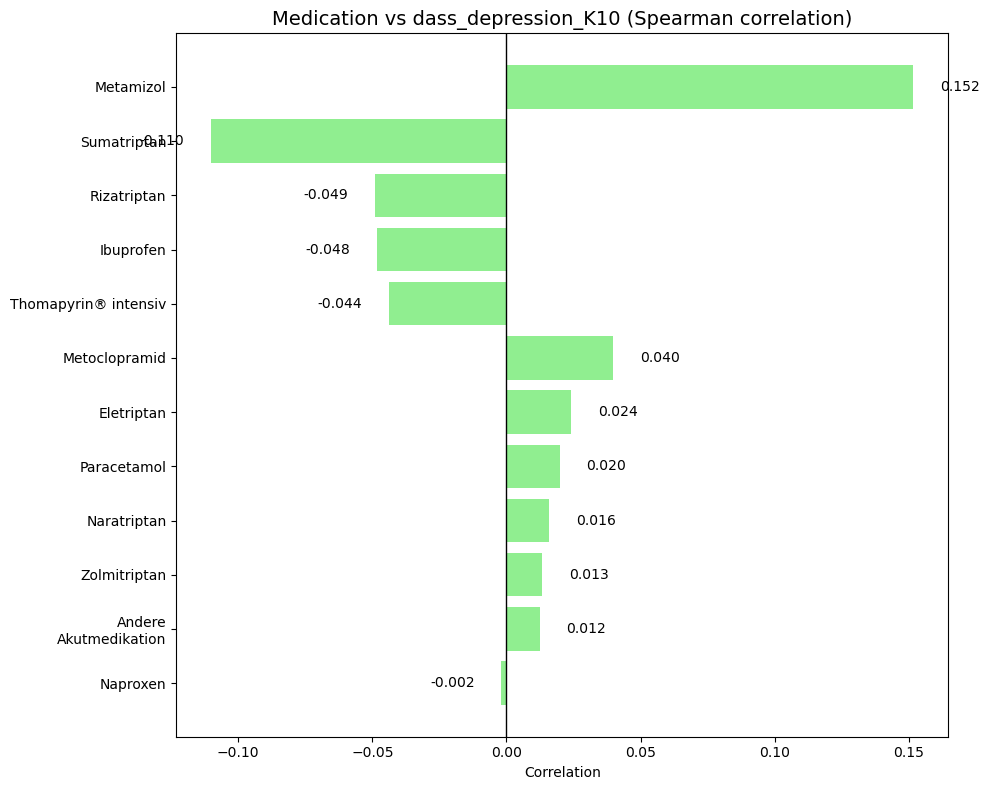

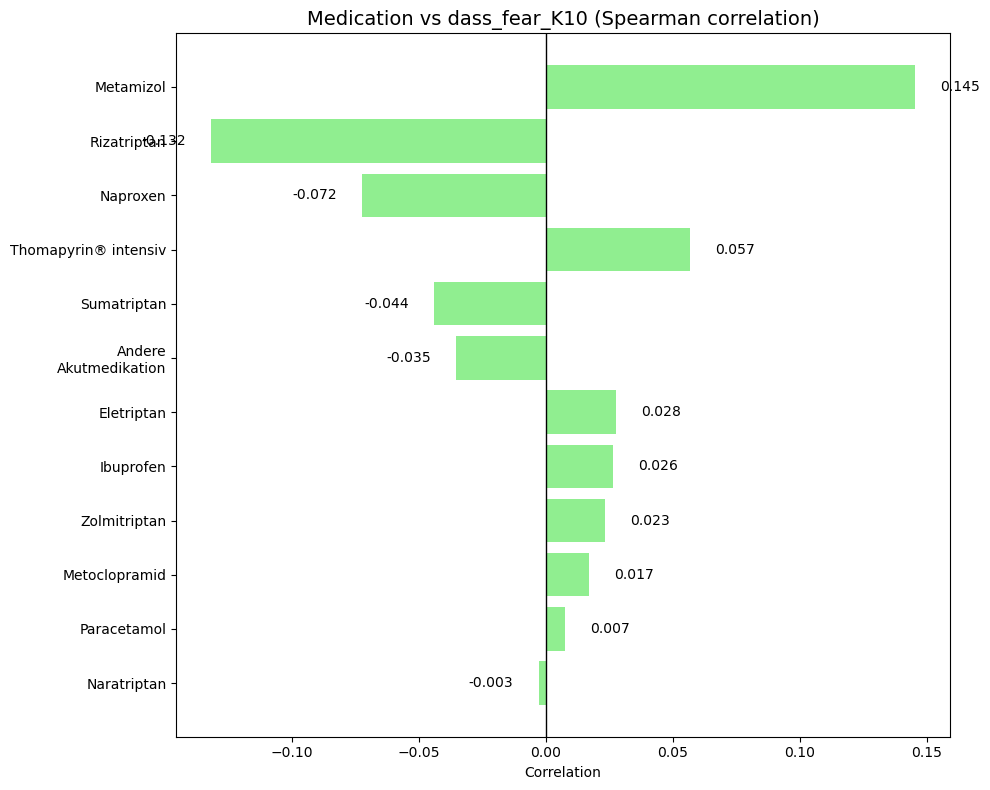

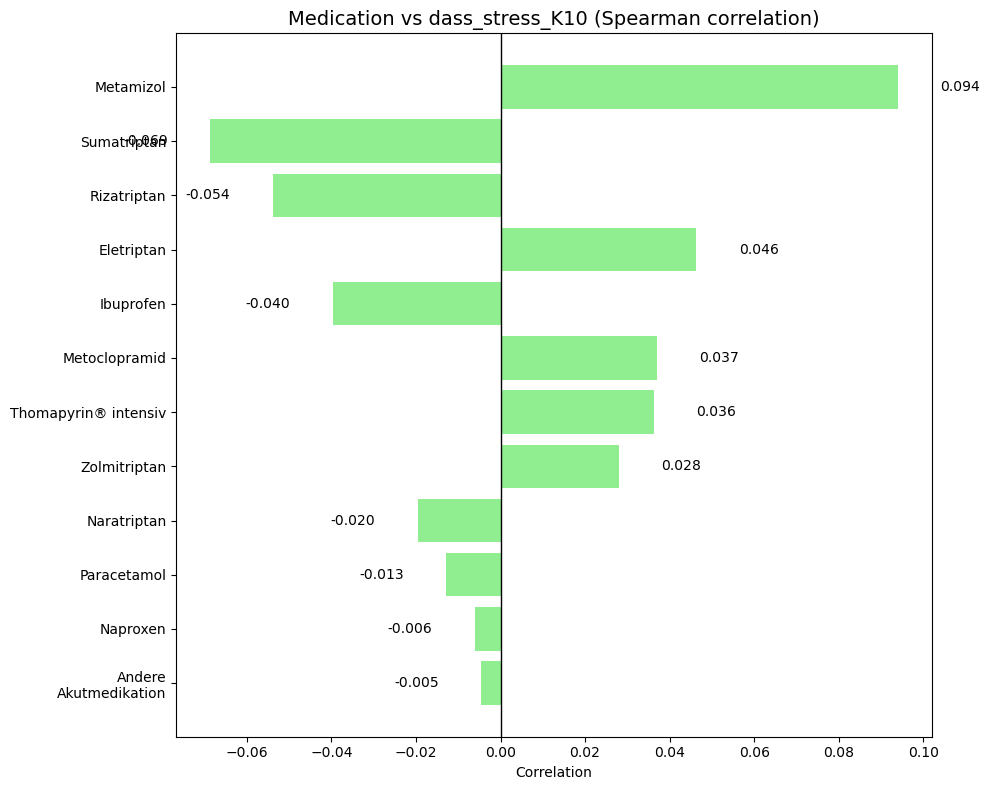

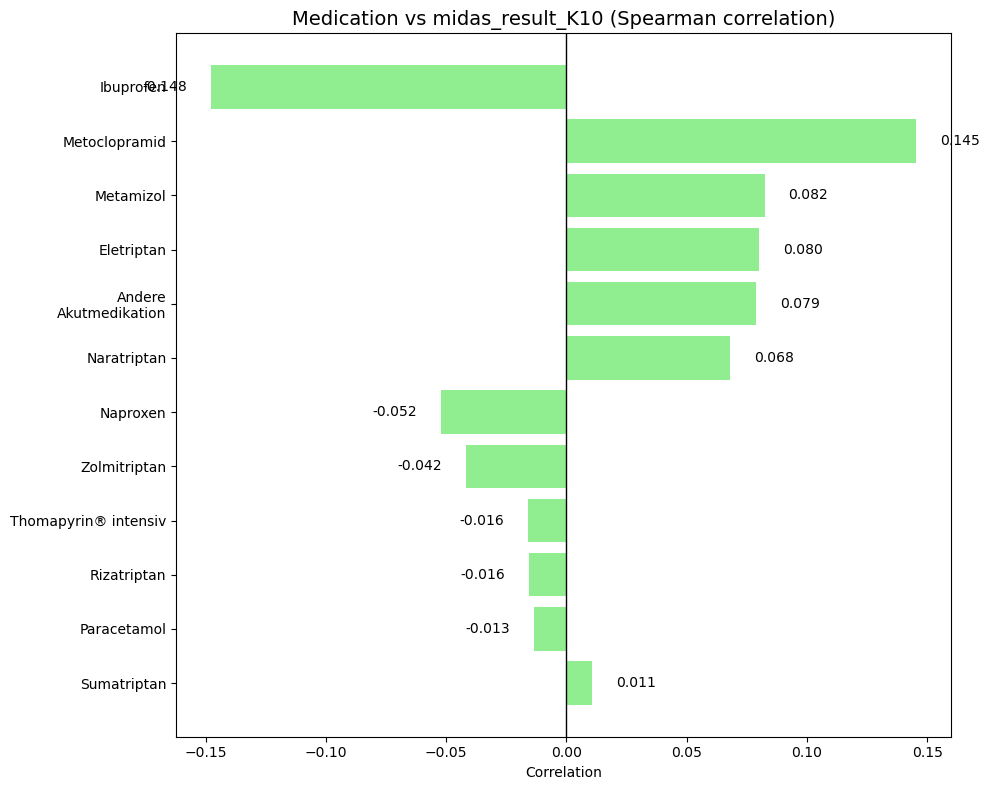

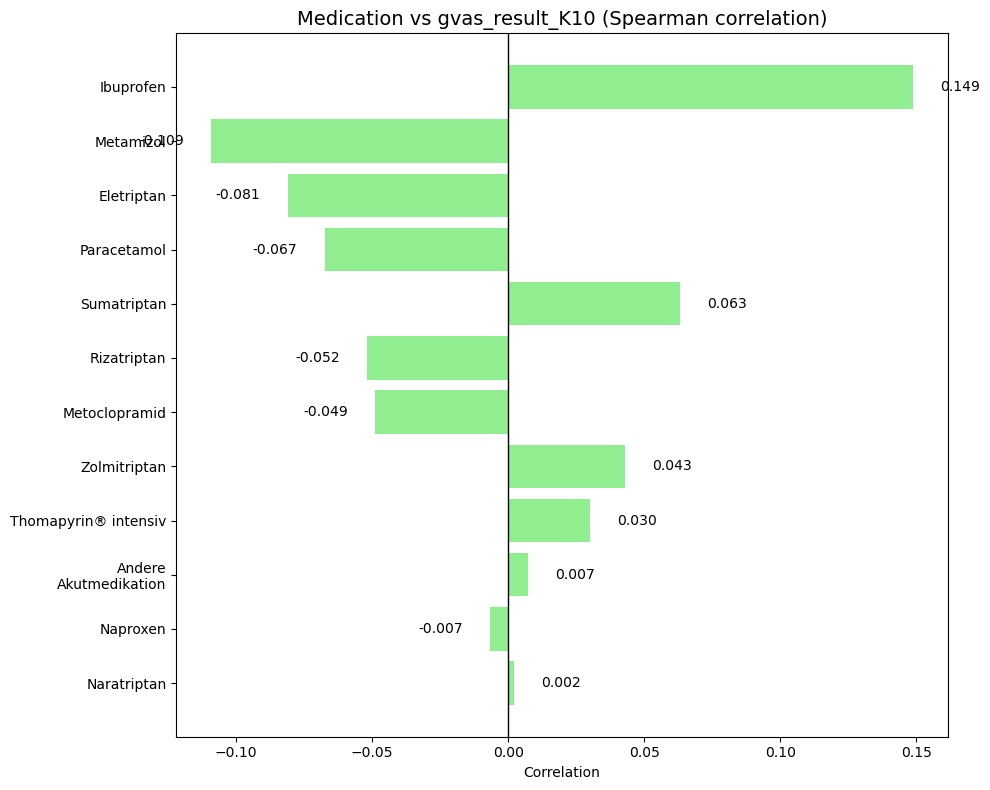

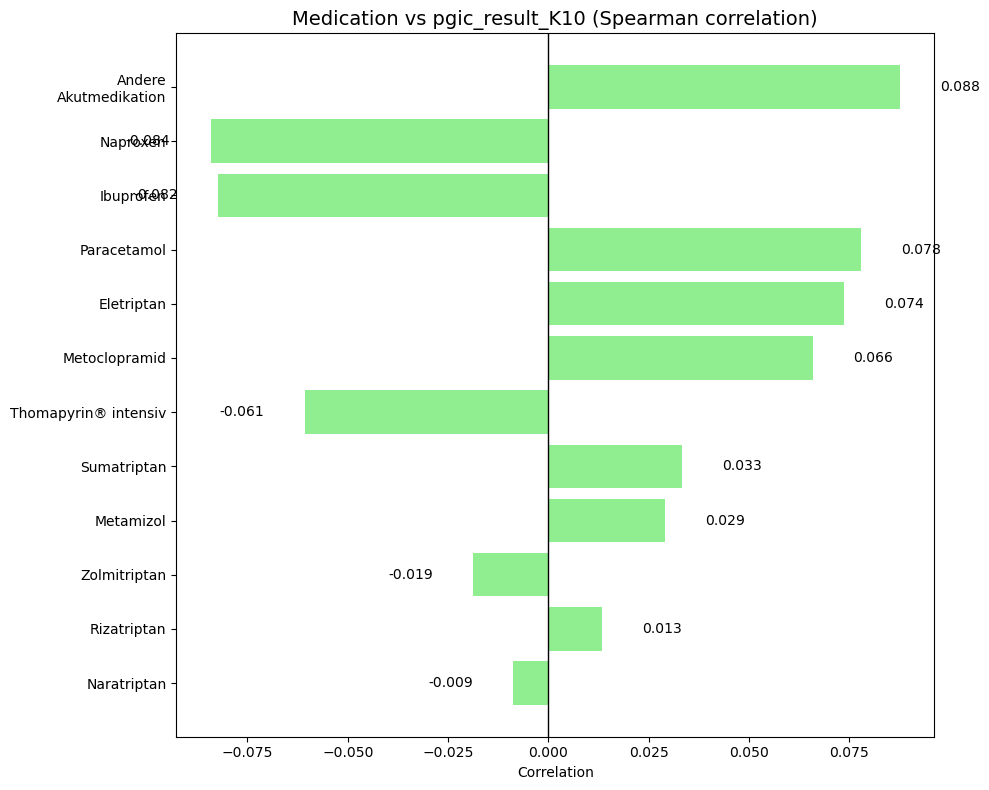

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import textwrap

# -----------------------
# LOAD DATA
# -----------------------

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

dfs = [pd.read_csv(f, sep=";") for f in csv_files]
data = pd.concat(dfs, ignore_index=True)

print("Rows:", len(data))

# -----------------------
# CLEAN FUNCTION
# -----------------------

def clean_name(name):
    name = str(name)
    name = name.replace(",", ".")
    name = pd.Series([name]).str.replace(r"_K\d+$", "", regex=True).iloc[0]
    name = name.replace("_K", "")
    return name

def to_numeric(s):
    return pd.to_numeric(
        s.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

# -----------------------
# QUESTIONNAIRE COLUMNS
# -----------------------

score_cols = [c for c in data.columns if any(
    c.startswith(x) for x in [
        "midas_result",
        "dass_depression",
        "dass_fear",
        "dass_stress",
        "gvas_result",
        "pgic_result",
        "chiq_result"
    ]
)]

print("Questionnaires:", score_cols)

# -----------------------
# MEDICATION COLUMNS
# -----------------------

med_cols = [c for c in data.columns if c.startswith("acute_name_a")]

print("Medication columns:", len(med_cols))

# -----------------------
# CLEAN MEDICATION DATA
# -----------------------

med_data = data[med_cols].copy()

for c in med_cols:
    med_data[c] = med_data[c].apply(clean_name)

# reshape to long format
med_long = med_data.melt(value_name="med").dropna()
med_long = med_long[med_long["med"] != "nan"]

# one-hot encode medications
med_dummies = pd.get_dummies(med_long["med"])

# rebuild per patient row
med_matrix = med_dummies.groupby(med_long.index).max()

# align safely
med_matrix = med_matrix.reindex(data.index, fill_value=0).astype(float)

# -----------------------
# SCORE DATA (CLEAN)
# -----------------------

scores = data[score_cols].apply(to_numeric)

# -----------------------
# CORRELATION + PLOTS (DISPLAY ONLY)
# -----------------------

for score in score_cols:

    y = pd.to_numeric(scores[score], errors="coerce").astype(float)

    # align rows
    mask = ~y.isna()
    y = y[mask]
    X = med_matrix.loc[mask]

    correlations = []

    for med in X.columns:

        x = X[med]

        # skip rare meds
        if x.sum() < 5:
            continue

        # ensure clean numeric
        x_clean = pd.to_numeric(x, errors="coerce").fillna(0)

        y_clean = pd.to_numeric(y, errors="coerce")

        valid = ~(np.isnan(x_clean) | np.isnan(y_clean))

        if valid.sum() < 10:
            continue

        try:
            corr, _ = spearmanr(x_clean[valid], y_clean[valid])
        except Exception:
            continue

        if np.isnan(corr):
            continue

        correlations.append((med, corr))

    if not correlations:
        continue

    # sort strongest associations
    correlations = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)[:15]

    meds, vals = zip(*correlations)
    meds_wrapped = [textwrap.fill(str(m), width=20) for m in meds]

    # -----------------------
    # PLOT
    # -----------------------

    plt.figure(figsize=(10, 8))
    bars = plt.barh(meds_wrapped[::-1], vals[::-1], color="lightgreen")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Medication vs {score} (Spearman correlation)", fontsize=14)
    plt.xlabel("Correlation")

    for i, bar in enumerate(bars):
        width = bar.get_width()
        ha = 'left' if width >= 0 else 'right'
        offset = 0.01 if width >= 0 else -0.01
        plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha=ha)

    plt.tight_layout()
    plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
import re

# ============================================================
# LOAD DATA
# ============================================================

DATA_DIR = Path("./patienten-visiten")

csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

dfs = [pd.read_csv(f, sep=";") for f in csv_files]
data = pd.concat(dfs, ignore_index=True)

print("Rows:", len(data))

# ============================================================
# HELPERS
# ============================================================

def clean_name(name):
    if pd.isna(name):
        return np.nan

    name = str(name)

    name = name.replace(",", ".")

    # remove trailing _K1, _K2, ...
    name = re.sub(r"_K\d+$", "", name)

    # remove trailing _K
    name = re.sub(r"_K$", "", name)

    return name.strip()


def to_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )


C:\Users\veron\AppData\Local\Temp\ipykernel_14192\1589379021.py:16: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Rows: 24497


In [4]:
# ============================================================
# FIND QUESTIONNAIRE COLUMNS
# ============================================================

questionnaire_prefixes = [
    "midas_result",
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "gvas_result",
    "pgic_result",
    "chiq_result"
]

questionnaire_groups = {}

for col in data.columns:

    for prefix in questionnaire_prefixes:

        if re.match(fr"^{prefix}_K\d+$", col):

            questionnaire_groups.setdefault(prefix, []).append(col)

# sort K columns numerically
for q in questionnaire_groups:

    questionnaire_groups[q] = sorted(
        questionnaire_groups[q],
        key=lambda x: int(re.search(r"_K(\d+)$", x).group(1))
    )

print("\nQuestionnaires found:")

for q, cols in questionnaire_groups.items():
    print(f"{q}: {len(cols)} visits")

# ============================================================
# COMBINE QUESTIONNAIRE K VALUES
# ============================================================

combined_scores = {}

for questionnaire, cols in questionnaire_groups.items():

    combined_scores[questionnaire] = (
        data[cols]
        .apply(to_numeric)
        .mean(axis=1)
    )



Questionnaires found:
dass_depression: 23 visits
dass_fear: 23 visits
dass_stress: 23 visits
midas_result: 23 visits
gvas_result: 23 visits
pgic_result: 23 visits
chiq_result: 23 visits


In [5]:
# ============================================================
# FIND MEDICATION COLUMNS
# ============================================================

med_cols = [
    c for c in data.columns
    if c.startswith("acute_name_a")
]

print("\nMedication columns:", len(med_cols))

# ============================================================
# BUILD MEDICATION MATRIX
# ============================================================

med_matrix = pd.DataFrame(index=data.index)

all_meds = set()

for col in med_cols:

    meds = data[col].apply(clean_name)

    unique_meds = meds.dropna().unique()

    all_meds.update(unique_meds)

all_meds = sorted(all_meds)

print("Unique medications:", len(all_meds))

# one-hot encoding
for med in all_meds:

    med_matrix[med] = 0

for col in med_cols:

    meds = data[col].apply(clean_name)

    for med in all_meds:

        mask = meds == med

        med_matrix.loc[mask, med] = 1

# force numeric
med_matrix = med_matrix.astype(float)



Medication columns: 288
Unique medications: 61


In [6]:
# ============================================================
# CORRELATION + PLOTS
# ============================================================

MIN_MED_OCCURRENCES = 5

for questionnaire, y in combined_scores.items():

    print(f"\n{'='*60}")
    print(questionnaire)
    print('='*60)

    y = pd.to_numeric(y, errors="coerce")

    correlations = []

    for med in med_matrix.columns:

        x = med_matrix[med]

        # skip very rare medications
        if x.sum() < MIN_MED_OCCURRENCES:
            continue

        valid = ~(x.isna() | y.isna())

        if valid.sum() < 10:
            continue

        try:
            corr, p = spearmanr(
                x[valid].astype(float),
                y[valid].astype(float)
            )

            if np.isnan(corr):
                continue

            correlations.append(
                {
                    "medication": med,
                    "correlation": corr,
                    "p_value": p,
                    "n": int(valid.sum())
                }
            )

        except Exception:
            continue

    if len(correlations) == 0:

        print("No valid correlations found.")
        continue

    corr_df = pd.DataFrame(correlations)

    corr_df["abs_corr"] = corr_df["correlation"].abs()

    corr_df = corr_df.sort_values(
        "abs_corr",
        ascending=False
    )

    top_n = min(20, len(corr_df))

    plot_df = corr_df.head(top_n)

    print(
        plot_df[
            ["medication", "correlation", "p_value"]
        ].round(4)
    )



dass_depression
                                   medication  correlation  p_value
20                                  Metamizol       0.0647   0.0000
4                       Andere Akutmedikation       0.0448   0.0000
34                                Rizatriptan      -0.0329   0.0000
9                                  Diclofenac       0.0328   0.0000
2                          Acetylsalicylsäure       0.0319   0.0000
10                              Dimenhydrinat       0.0307   0.0000
43                                    Tilidin       0.0302   0.0001
35                                 Sauerstoff       0.0240   0.0014
32                Paracetamol/Ibuprofen Acino       0.0205   0.0062
38  Suvexx® (Sumatriptan/Naproxen 85mg/500mg)      -0.0190   0.0110
19                                 Lasmiditan      -0.0186   0.0128
47                                   Tramadol       0.0184   0.0137
3                                 Almotriptan      -0.0163   0.0295
24                             

C:\Users\veron\AppData\Local\Temp\ipykernel_14192\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\3762607140.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\3762607140.py:31: Constan


QUESTIONNAIRE: dass_depression
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\dass_depression_medication_correlation.png


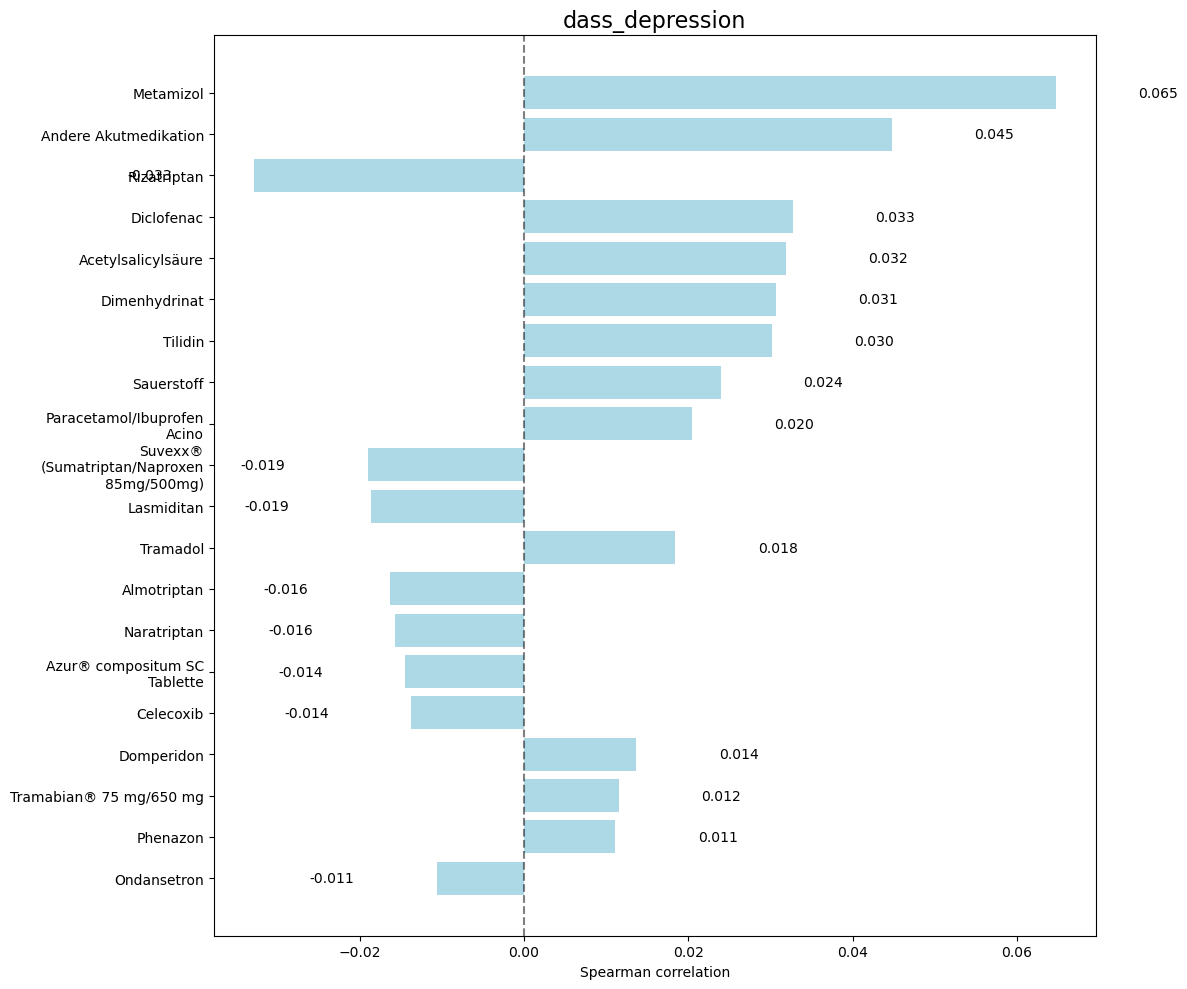


QUESTIONNAIRE: dass_fear
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\dass_fear_medication_correlation.png


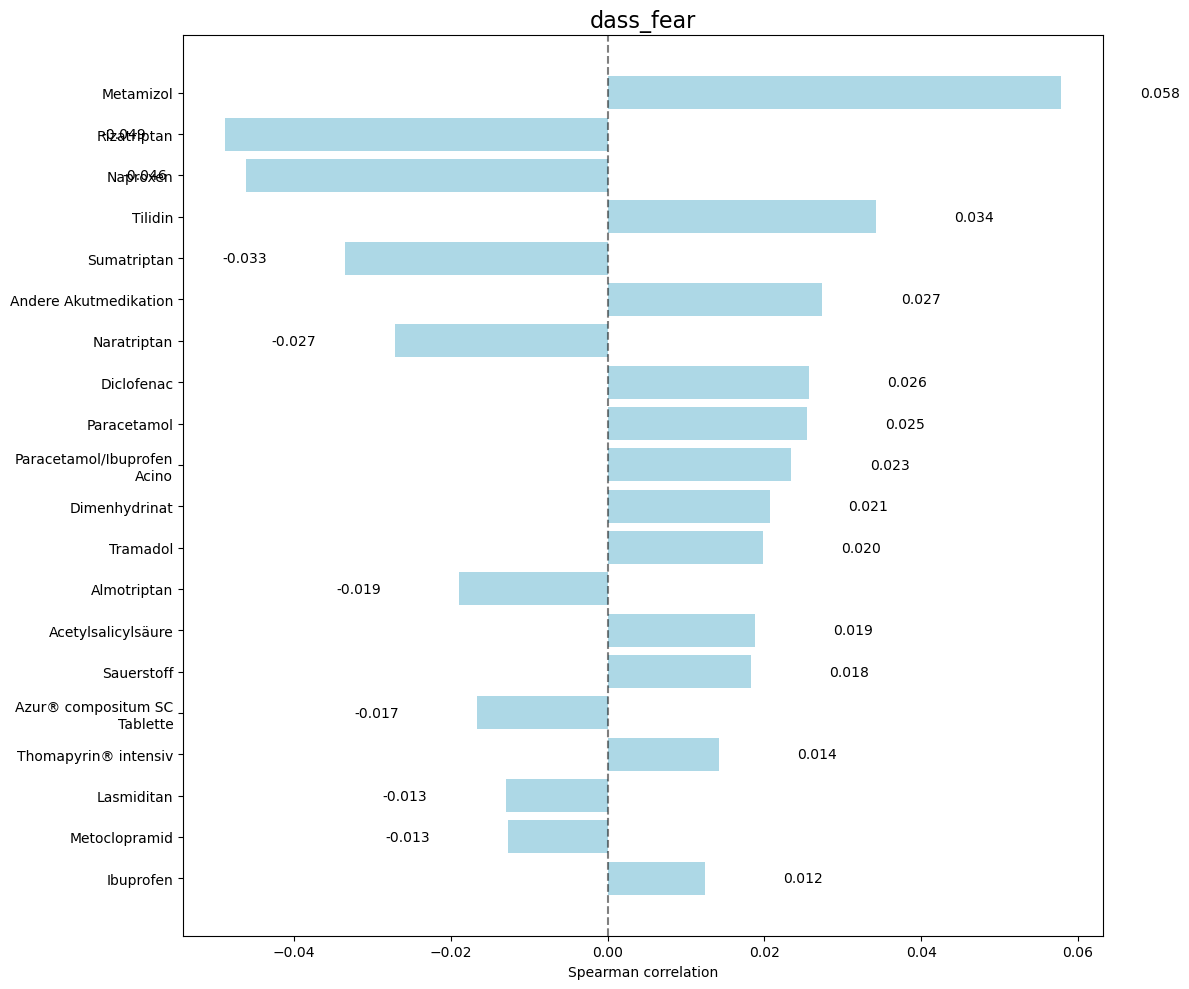


QUESTIONNAIRE: dass_stress
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\dass_stress_medication_correlation.png


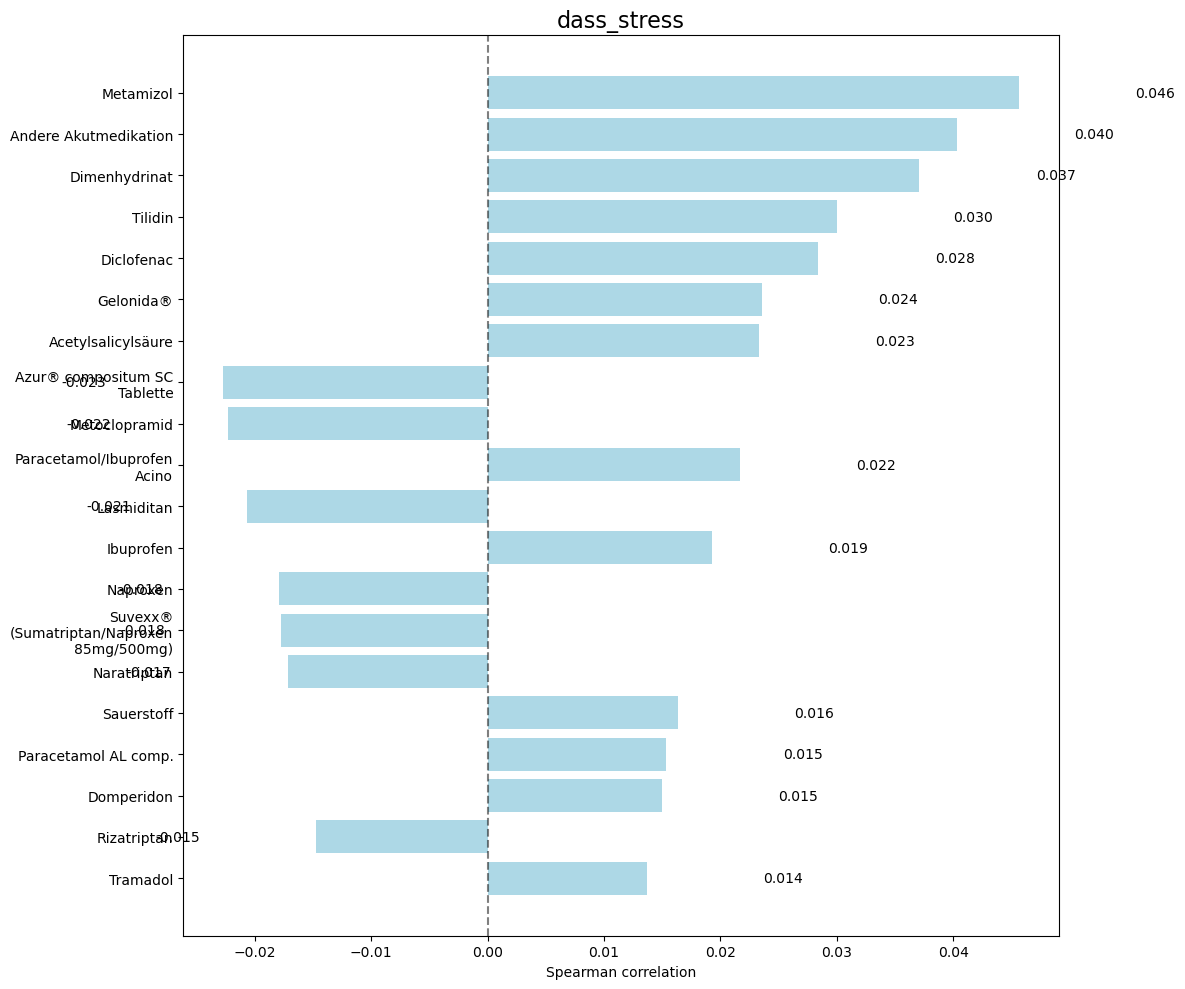


QUESTIONNAIRE: midas_result
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\midas_result_medication_correlation.png


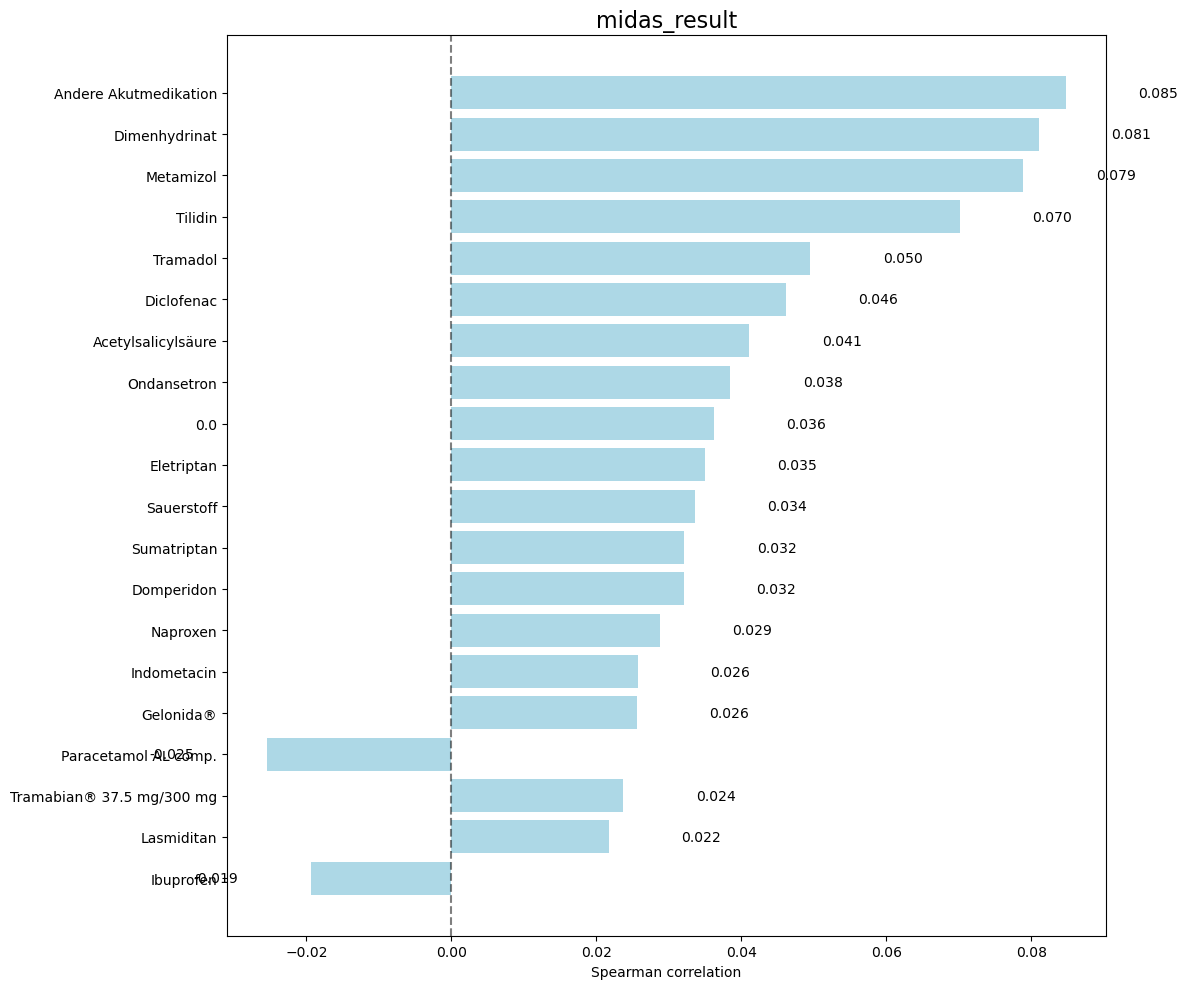


QUESTIONNAIRE: gvas_result
Y non-null: 17866
Valid correlations found: 49
Saved: correlation_plots\gvas_result_medication_correlation.png


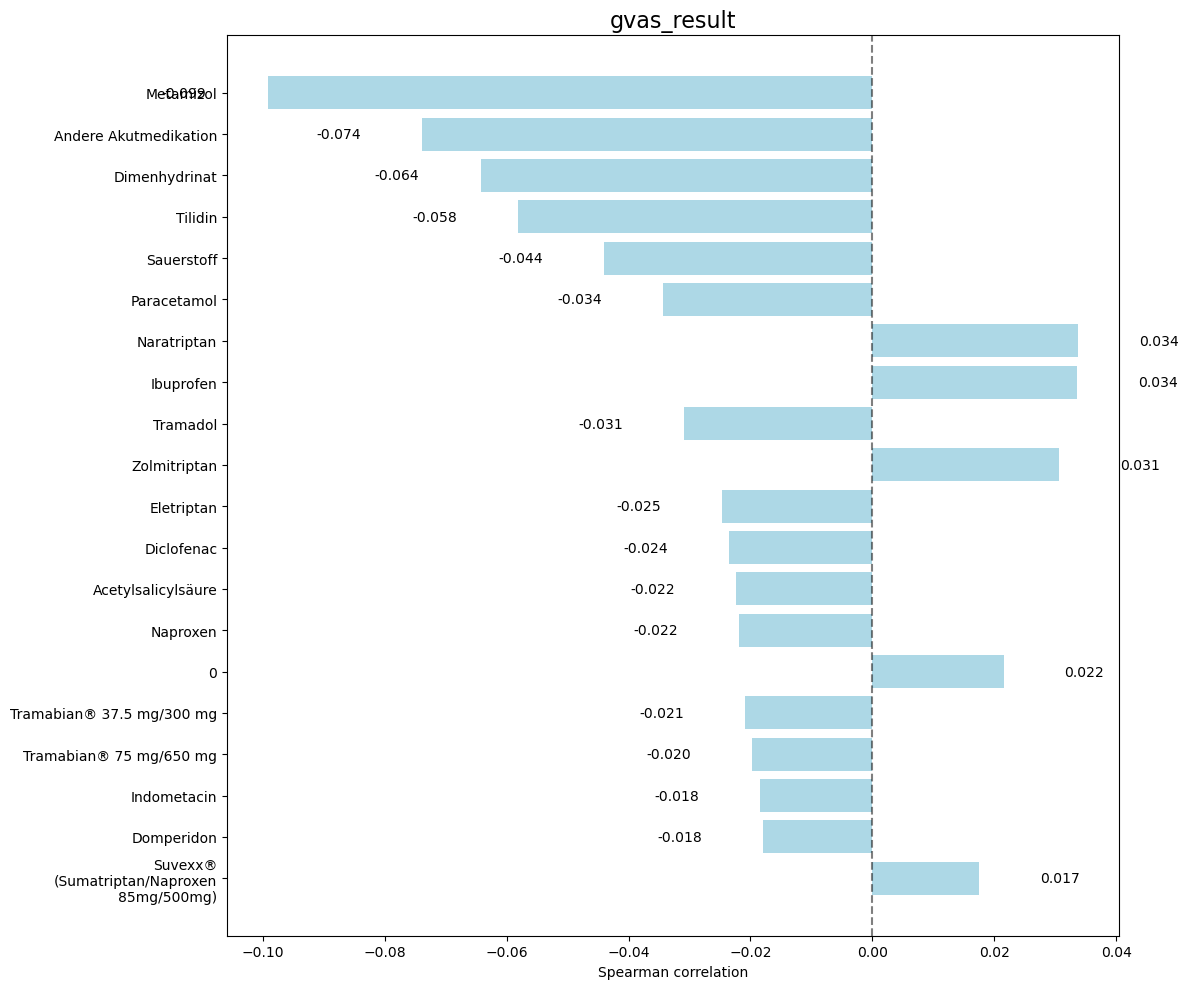


QUESTIONNAIRE: pgic_result
Y non-null: 11235


C:\Users\veron\AppData\Local\Temp\ipykernel_14192\2505367537.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(


Valid correlations found: 48
Saved: correlation_plots\pgic_result_medication_correlation.png


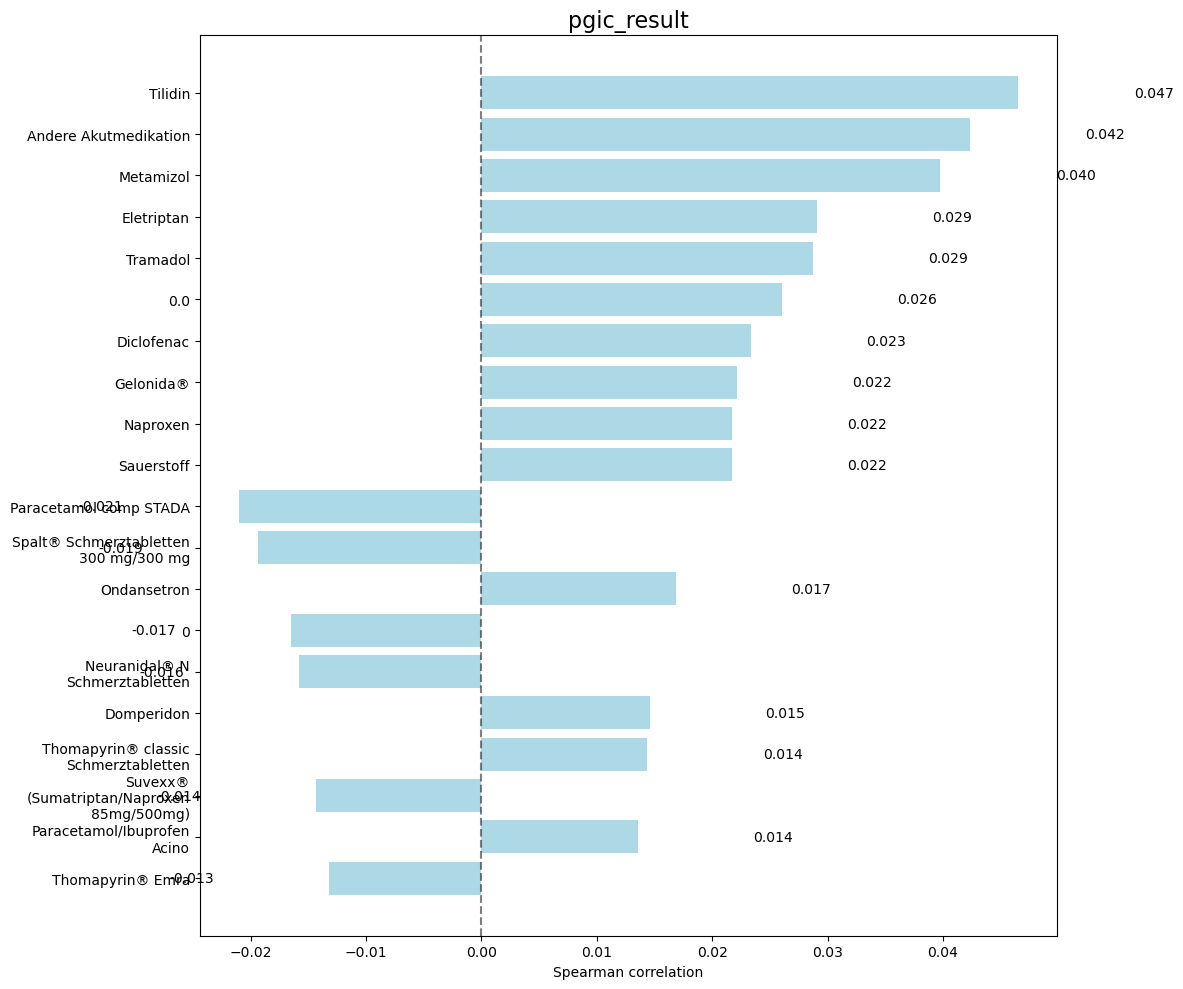


QUESTIONNAIRE: chiq_result
Y non-null: 192
Valid correlations found: 21


C:\Users\veron\AppData\Local\Temp\ipykernel_14192\2505367537.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\2505367537.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\2505367537.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\2505367537.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\2505367537.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(
C:\Users\veron\AppData\Local\Temp\ipykernel_14192\2505367537.py:30: Constan

Saved: correlation_plots\chiq_result_medication_correlation.png


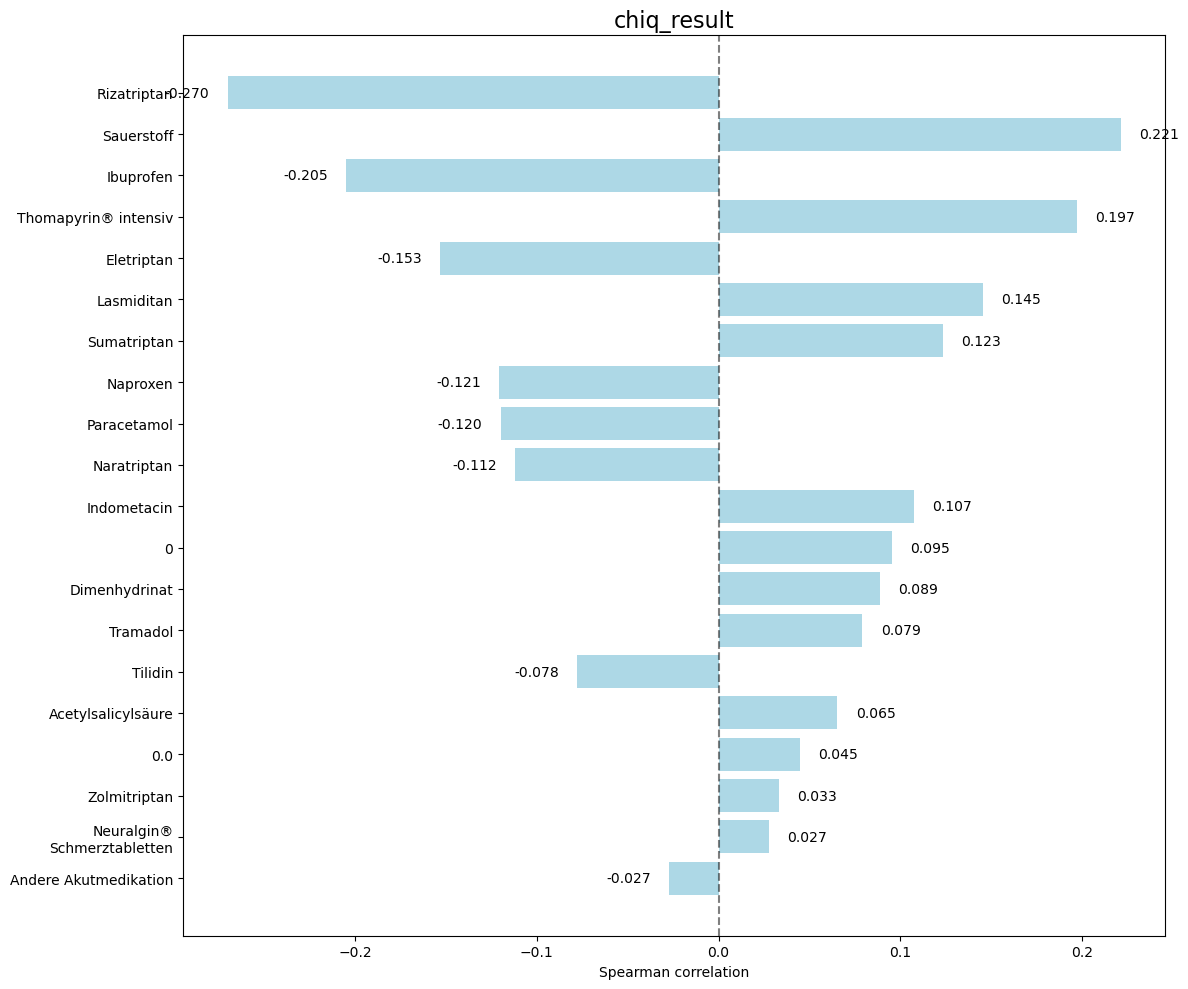

In [7]:
for questionnaire, y in combined_scores.items():

    print("\n" + "="*60)
    print("QUESTIONNAIRE:", questionnaire)
    print("="*60)

    y = pd.to_numeric(y, errors="coerce")

    print("Y non-null:", y.notna().sum())

    correlations = []

    for med in med_matrix.columns:

        x = med_matrix[med]

        # basic stats
        x_sum = x.sum()
        y_valid = ~(x.isna() | y.isna())
        n = y_valid.sum()

        # DEBUG OUTPUT (IMPORTANT)
        if x_sum < 5:
            continue

        if n < 10:
            continue

        try:
            corr, p = spearmanr(
                x[y_valid].astype(float),
                y[y_valid].astype(float)
            )

            if np.isnan(corr):
                continue

            correlations.append((med, corr))

        except Exception as e:
            print(f"FAILED {med}: {e}")

    print("Valid correlations found:", len(correlations))

    if len(correlations) == 0:
        print("NO DATA FOR PLOT → check missing values / overlap")
        continue

    correlations = sorted(
        correlations,
        key=lambda x: abs(x[1]),
        reverse=True
    )[:20]

    meds, vals = zip(*correlations)
    meds_wrapped = [textwrap.fill(str(m), width=25) for m in meds]

    plt.figure(figsize=(12, max(8, len(meds) * 0.5)))

    bars = plt.barh(meds_wrapped[::-1], vals[::-1], color="lightblue")

    plt.axvline(0, linestyle="--", color="black", alpha=0.5)

    plt.title(f"{questionnaire}", fontsize=16)
    plt.xlabel("Spearman correlation")

    for bar in bars:
        width = bar.get_width()
        ha = 'left' if width >= 0 else 'right'
        offset = 0.01 if width >= 0 else -0.01
        plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha=ha)

    plt.tight_layout()

    import os

    SAVE_DIR = "correlation_plots"
    os.makedirs(SAVE_DIR, exist_ok=True)

    filename = f"{questionnaire}_medication_correlation.png"
    filepath = os.path.join(SAVE_DIR, filename)

    plt.savefig(filepath, dpi=200, bbox_inches="tight")
    print("Saved:", filepath)

    plt.show()

C:\Users\veron\AppData\Local\Temp\ipykernel_14192\3951590631.py:52: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(


Saved: correlation_plots\combined_questionnaire_medication_correlations.png


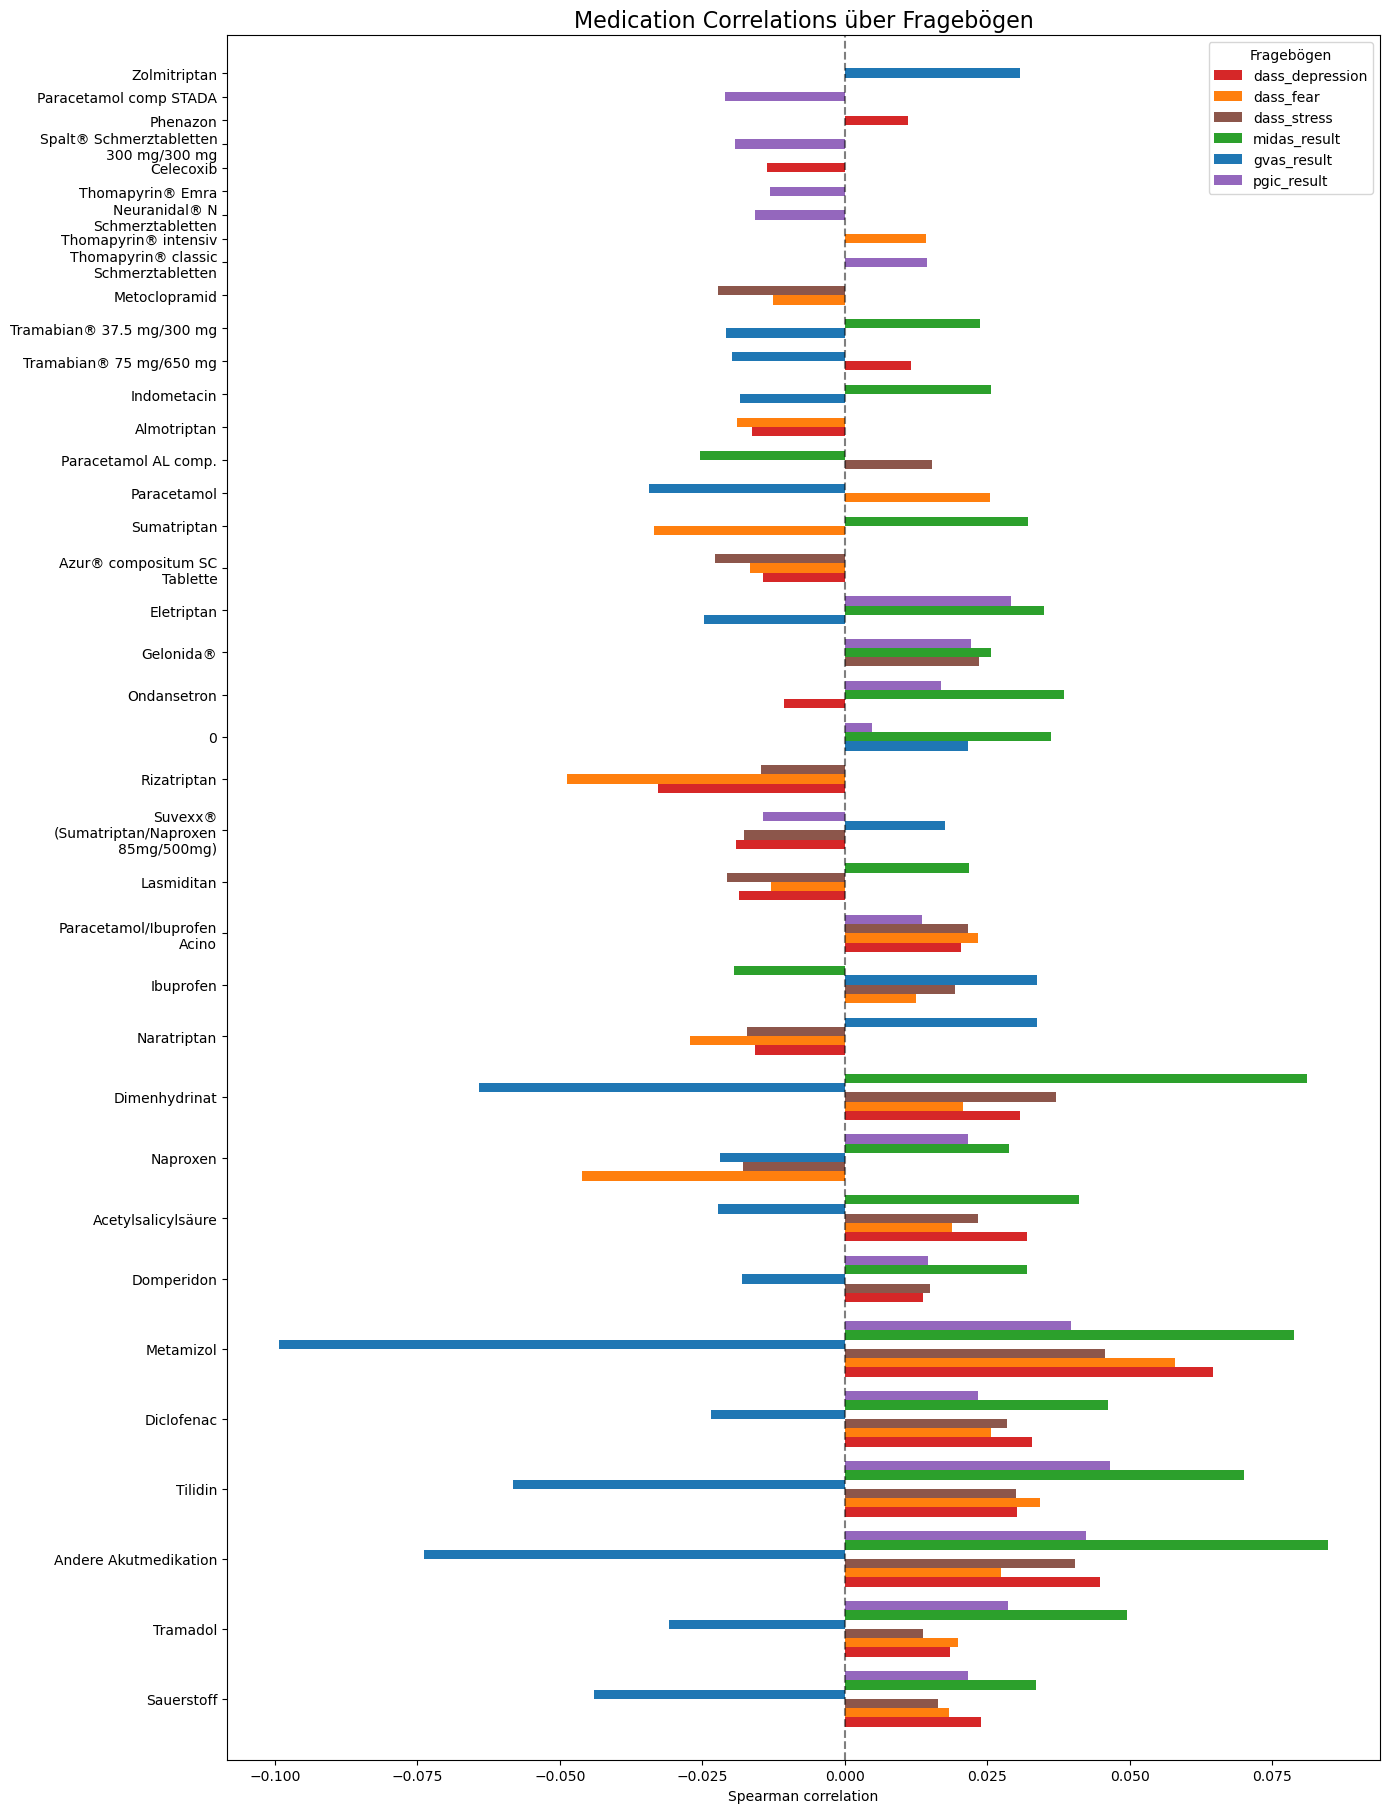

In [8]:
# ============================================================
# KOMBINIERTE DIAGRAMME – ANGEPASSTE DARSTELLUNG
# ============================================================

selected_questionnaires = [
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "midas_result",
    "gvas_result",
    "pgic_result"
]

questionnaire_colors = {
    "dass_depression": "tab:red",
    "dass_fear": "tab:orange",
    "dass_stress": "tab:brown",
    "midas_result": "tab:green",
    "gvas_result": "tab:blue",
    "pgic_result": "tab:purple"
}

combined_correlations = []

for questionnaire in selected_questionnaires:

    if questionnaire not in combined_scores:
        print(f"{questionnaire} nicht gefunden - wird übersprungen")
        continue

    y = pd.to_numeric(
        combined_scores[questionnaire],
        errors="coerce"
    )

    correlations = []

    for med in med_matrix.columns:

        x = med_matrix[med]

        if x.sum() < MIN_MED_OCCURRENCES:
            continue

        valid = ~(x.isna() | y.isna())

        if valid.sum() < 10:
            continue

        try:

            corr, p = spearmanr(
                x[valid].astype(float),
                y[valid].astype(float)
            )

            if np.isnan(corr):
                continue

            correlations.append(
                {
                    "questionnaire": questionnaire,
                    "medication": med,
                    "correlation": corr,
                    "p_value": p,
                    "n": int(valid.sum())
                }
            )

        except Exception:
            continue

    if len(correlations) == 0:
        continue

    corr_df = pd.DataFrame(correlations)

    corr_df["abs_corr"] = corr_df["correlation"].abs()

    corr_df = corr_df.sort_values(
        "abs_corr",
        ascending=False
    ).head(20)

    combined_correlations.extend(
        corr_df.to_dict("records")
    )

# ============================================================
# GEMEINSAMES DIAGRAMM
# ============================================================

if len(combined_correlations) == 0:

    print(
        "Keine gültigen Korrelationen für das kombinierte Diagramm gefunden."
    )

else:

    combined_df = pd.DataFrame(
        combined_correlations
    )

    # 0 und 0.0 als derselbe Medikamentenname
    combined_df["medication"] = (
        combined_df["medication"]
        .astype(str)
        .str.strip()
        .replace({
            "0.0": "0"
        })
    )

    # Falls durch die Normalisierung doppelte Einträge entstehen
    combined_df = (
        combined_df
        .groupby(
            ["questionnaire", "medication"],
            as_index=False
        )["correlation"]
        .mean()
    )

    # ========================================================
    # MEDIKAMENTE NACH ANZAHL DER FRAGEBOGEN SORTIEREN
    # ========================================================

    medication_questionnaire_counts = (
        combined_df
        .groupby("medication")["questionnaire"]
        .nunique()
        .sort_values(
            ascending=False
        )
    )

    medications = (
        medication_questionnaire_counts
        .index
        .tolist()
    )

    # ========================================================
    # VARIABLE VERTIKALE ABSTÄNDE
    #
    # Mehr Fragebogenwerte = mehr vertikaler Platz
    # Weniger Fragebogenwerte = weniger vertikaler Platz
    # ========================================================

    questionnaire_count_per_medication = {
        med: medication_questionnaire_counts.loc[med]
        for med in medications
    }

    y_positions = []

    current_y = 0

    for i, med in enumerate(
        medications
    ):

        y_positions.append(
            current_y
        )

        n_questionnaires = (
            questionnaire_count_per_medication[
                med
            ]
        )

        # Höhe der Gruppe proportional
        # zur Anzahl vorhandener Fragebogen
        group_height = (
            n_questionnaires
            * 0.18
        )

        # Grundabstand zwischen Medikamenten
        # wird nur proportional ergänzt
        if i < len(medications) - 1:

            current_y += (
                group_height
                + 0.28
            )

    y_positions = np.array(
        y_positions
    )

    # ========================================================
    # PLOT
    # ========================================================

    questionnaire_count = len(
        selected_questionnaires
    )

    bar_height = 0.18

    plt.figure(
        figsize=(
            14,
            max(
                10,
                len(medications) * 0.48
            )
        )
    )

    for i, questionnaire in enumerate(
        selected_questionnaires
    ):

        q_df = combined_df[
            combined_df["questionnaire"]
            == questionnaire
        ]

        if len(q_df) == 0:
            continue

        q_df = q_df.set_index(
            "medication"
        )

        for med, y_position in zip(
            medications,
            y_positions
        ):

            if med not in q_df.index:
                continue

            value = q_df.loc[
                med,
                "correlation"
            ]

            # Position des einzelnen Fragebogens
            # innerhalb der Medikamentengruppe
            med_questionnaires = (
                combined_df[
                    combined_df["medication"]
                    == med
                ]["questionnaire"]
                .tolist()
            )

            local_index = (
                med_questionnaires
                .index(
                    questionnaire
                )
            )

            local_count = len(
                med_questionnaires
            )

            local_offset = (
                local_index
                - (
                    local_count - 1
                ) / 2
            ) * bar_height

            plt.barh(
                y_position
                + local_offset,
                value,
                height=bar_height,
                color=questionnaire_colors[
                    questionnaire
                ],
                label=(
                    questionnaire
                    if med == medications[0]
                    else None
                )
            )

    meds_wrapped = [
        textwrap.fill(
            str(med),
            width=25
        )
        for med in medications
    ]


    plt.yticks(
        y_positions,
        meds_wrapped
    )

    plt.axvline(
        0,
        linestyle="--",
        color="black",
        alpha=0.5
    )

    plt.title(
        "Medication Correlations über Fragebögen",
        fontsize=16
    )

    plt.xlabel(
        "Spearman correlation"
    )

    plt.legend(
        title="Fragebögen"
    )

    # Abstand zwischen den Medikamenten,
    # aber kein zusätzlicher Abstand zwischen
    # Titel und Diagramm
    plt.margins(
        y=0.02
    )

    plt.tight_layout()

    SAVE_DIR = "correlation_plots"

    os.makedirs(
        SAVE_DIR,
        exist_ok=True
    )

    filename = (
        "combined_questionnaire_medication_correlations.png"
    )

    filepath = os.path.join(
        SAVE_DIR,
        filename
    )

    plt.savefig(
        filepath,
        dpi=200,
        bbox_inches="tight"
    )

    print(
        "Saved:",
        filepath
    )

    plt.show()

C:\Users\veron\AppData\Local\Temp\ipykernel_14192\732257020.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(


Saved: correlation_plots\combined_questionnaire_medication_heatmap.png


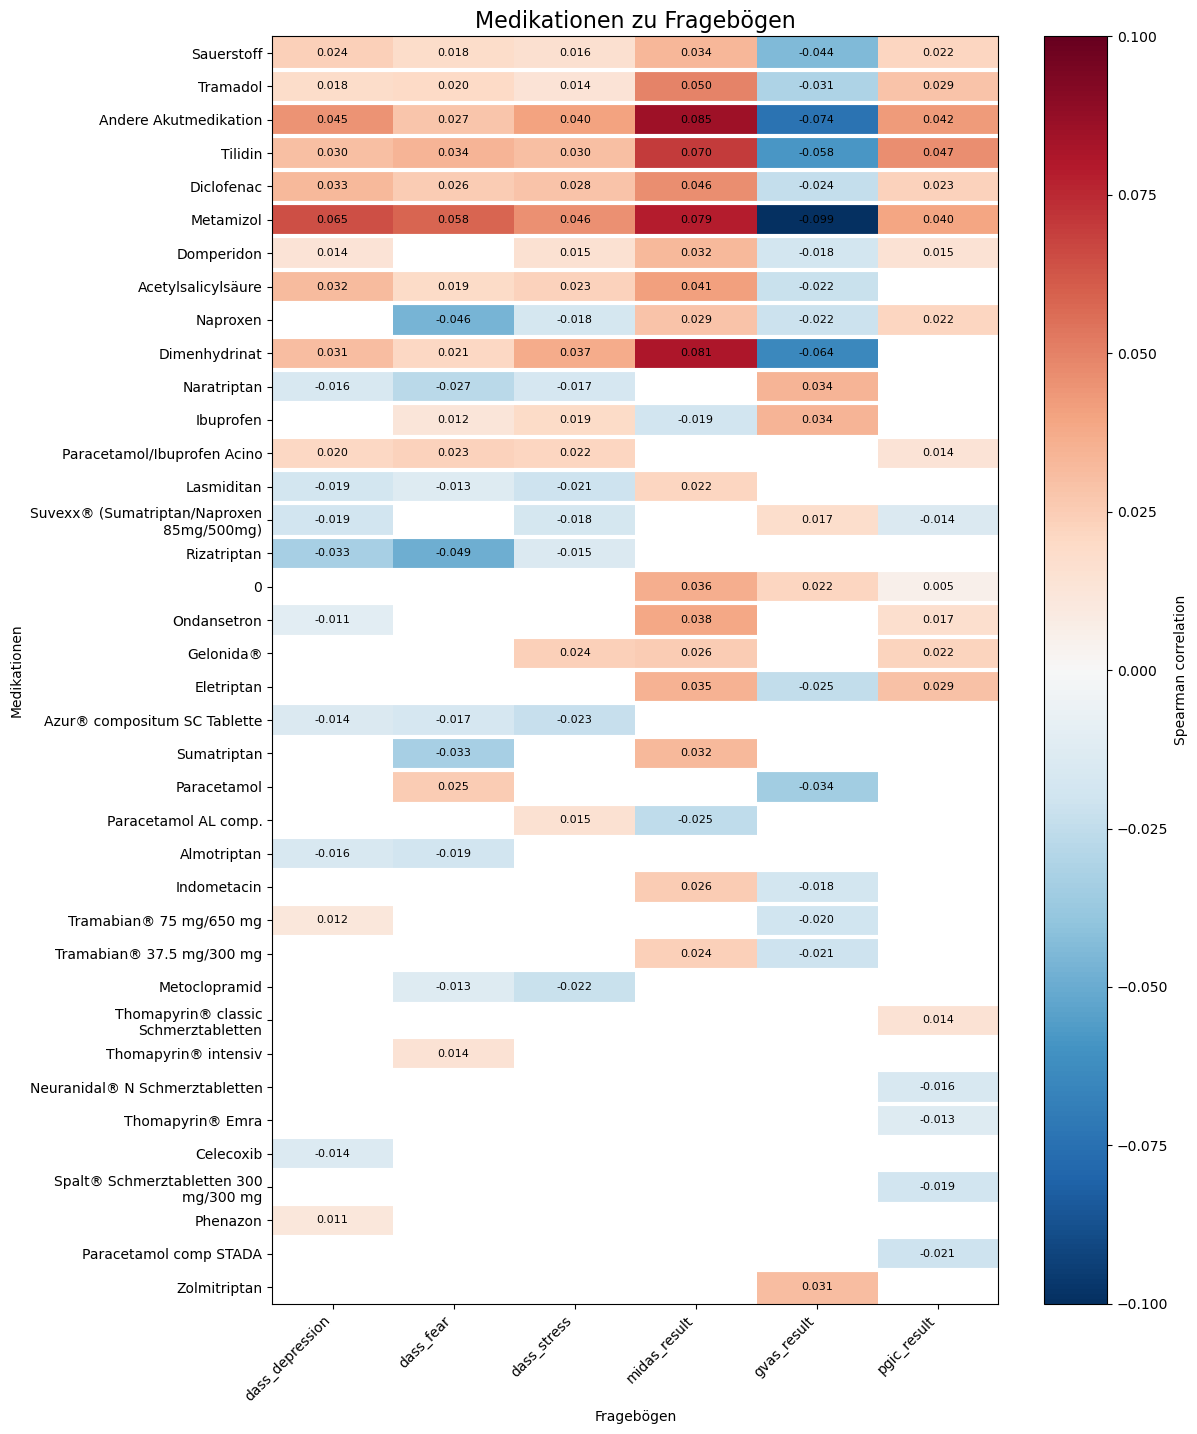

In [9]:
# ============================================================
# KOMBINIERTE HEATMAP
# ============================================================

selected_questionnaires = [
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "midas_result",
    "gvas_result",
    "pgic_result"
]

combined_correlations = []

for questionnaire in selected_questionnaires:

    if questionnaire not in combined_scores:
        print(
            f"{questionnaire} nicht gefunden - wird übersprungen"
        )
        continue

    y = pd.to_numeric(
        combined_scores[questionnaire],
        errors="coerce"
    )

    correlations = []

    for med in med_matrix.columns:

        x = med_matrix[med]

        if x.sum() < MIN_MED_OCCURRENCES:
            continue

        valid = ~(x.isna() | y.isna())

        if valid.sum() < 10:
            continue

        try:

            corr, p = spearmanr(
                x[valid].astype(float),
                y[valid].astype(float)
            )

            if np.isnan(corr):
                continue

            correlations.append(
                {
                    "questionnaire": questionnaire,
                    "medication": med,
                    "correlation": corr,
                    "p_value": p,
                    "n": int(valid.sum())
                }
            )

        except Exception:
            continue

    if len(correlations) == 0:
        continue

    corr_df = pd.DataFrame(
        correlations
    )

    corr_df["abs_corr"] = (
        corr_df["correlation"].abs()
    )

    corr_df = corr_df.sort_values(
        "abs_corr",
        ascending=False
    ).head(20)

    combined_correlations.extend(
        corr_df.to_dict(
            "records"
        )
    )

# ============================================================
# HEATMAP
# ============================================================

if len(combined_correlations) == 0:

    print(
        "Keine gültigen Korrelationen für die Heatmap gefunden."
    )

else:

    combined_df = pd.DataFrame(
        combined_correlations
    )

    # ========================================================
    # 0 UND 0.0 ZUSAMMENFÜHREN
    # ========================================================

    combined_df["medication"] = (
        combined_df["medication"]
        .astype(str)
        .str.strip()
        .replace(
            {
                "0.0": "0"
            }
        )
    )

    # ========================================================
    # DOPPELTE MEDIKAMENTE ZUSAMMENFÜHREN
    # ========================================================

    combined_df = (
        combined_df
        .groupby(
            [
                "questionnaire",
                "medication"
            ],
            as_index=False
        )
        .agg(
            correlation=(
                "correlation",
                "mean"
            )
        )
    )

    # ========================================================
    # MEDIKAMENTE NACH ANZAHL VORHANDENER FRAGEBOGEN
    # ========================================================

    medication_questionnaire_counts = (
        combined_df
        .groupby(
            "medication"
        )["questionnaire"]
        .nunique()
        .sort_values(
            ascending=False
        )
    )

    medications = (
        medication_questionnaire_counts
        .index
        .tolist()
    )

    # ========================================================
    # MATRIX AUFBAUEN
    # ========================================================

    heatmap_data = (
        combined_df
        .pivot(
            index="medication",
            columns="questionnaire",
            values="correlation"
        )
    )

    # Reihenfolge der Fragebogen festlegen
    available_questionnaires = [
        q
        for q in selected_questionnaires
        if q in heatmap_data.columns
    ]

    heatmap_data = (
        heatmap_data
        .reindex(
            index=medications,
            columns=available_questionnaires
        )
    )

    # ========================================================
    # HEATMAP
    # ========================================================

    plt.figure(
        figsize=(
            12,
            max(
                8,
                len(medications) * 0.38
            )
        )
    )

    im = plt.imshow(
        heatmap_data.values,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-0.1,
        vmax=0.1
    )

    # ========================================================
    # KORRELATIONSWERTE IN DIE ZELLEN SCHREIBEN
    # ========================================================

    for row in range(
        heatmap_data.shape[0]
    ):

        for col in range(
            heatmap_data.shape[1]
        ):

            value = heatmap_data.iloc[
                row,
                col
            ]

            if not pd.isna(value):

                plt.text(
                    col,
                    row,
                    f"{value:.3f}",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=8
                )

    # ========================================================
    # ACHSEN
    # ========================================================

    plt.xticks(
        np.arange(
            len(available_questionnaires)
        ),
        available_questionnaires,
        rotation=45,
        ha="right"
    )

    meds_wrapped = [
        textwrap.fill(
            str(med),
            width=30
        )
        for med in medications
    ]

    plt.yticks(
        np.arange(
            len(medications)
        ),
        meds_wrapped
    )

    # ========================================================
    # COLORBAR
    # ========================================================

    cbar = plt.colorbar(
        im
    )

    cbar.set_label(
        "Spearman correlation"
    )

    # ========================================================
    # TITEL UND BESCHRIFTUNGEN
    # ========================================================

    plt.title(
        "Medikationen zu Fragebögen",
        fontsize=16
    )

    plt.xlabel(
        "Fragebögen"
    )

    plt.ylabel(
        "Medikationen"
    )

    # ========================================================
    # ABSTAND ZWISCHEN MEDIKAMENTEN
    # ========================================================

    plt.gca().set_yticks(
        np.arange(
            len(medications)
        )
    )

    # dünne horizontale Linien erzeugen
    # und die Medikamentenbereiche visuell trennen
    for y_pos in np.arange(
        len(medications) - 1
    ) + 0.5:

        plt.axhline(
            y_pos,
            color="white",
            linewidth=3
        )

    plt.tight_layout()

    # ========================================================
    # SPEICHERN
    # ========================================================

    SAVE_DIR = "correlation_plots"

    os.makedirs(
        SAVE_DIR,
        exist_ok=True
    )

    filename = (
        "combined_questionnaire_medication_heatmap.png"
    )

    filepath = os.path.join(
        SAVE_DIR,
        filename
    )

    plt.savefig(
        filepath,
        dpi=200,
        bbox_inches="tight"
    )

    print(
        "Saved:",
        filepath
    )

    plt.show()

In [10]:
# ============================================================
# AUSWERTUNG: MEDIKATIONEN ZU FRAGEBOGEN-KORRELATIONEN
# ============================================================

print("\n")
print("=" * 100)
print("AUSWERTUNG DER MEDIKATIONEN ZU FRAGEBOGEN-KORRELATIONEN")
print("=" * 100)

# ------------------------------------------------------------
# ALLE KORRELATIONEN ERNEUT BERECHNEN
# ------------------------------------------------------------

all_correlation_results = []

for questionnaire in selected_questionnaires:

    if questionnaire not in combined_scores:
        continue

    y = pd.to_numeric(
        combined_scores[questionnaire],
        errors="coerce"
    )

    for med in med_matrix.columns:

        x = med_matrix[med]

        # Medikamente mit weniger als 5 Vorkommen überspringen
        if x.sum() < MIN_MED_OCCURRENCES:
            continue

        valid = ~(x.isna() | y.isna())

        if valid.sum() < 10:
            continue

        try:

            corr, p_value = spearmanr(
                x[valid].astype(float),
                y[valid].astype(float)
            )

            if np.isnan(corr):
                continue

            all_correlation_results.append({

                "Medikament": med,

                "Fragebogen": questionnaire,

                "Spearman_r": corr,

                "p_Wert": p_value,

                "N": int(valid.sum()),

                "Medikament_N": int(x.sum())

            })

        except Exception:

            continue


# ------------------------------------------------------------
# DATAFRAME ERSTELLEN
# ------------------------------------------------------------

correlation_results_df = pd.DataFrame(
    all_correlation_results
)


# ------------------------------------------------------------
# INTERPRETATION DER KORRELATIONSSTÄRKE
# ------------------------------------------------------------

def interpret_correlation(r):

    r_abs = abs(r)

    if r_abs < 0.10:
        strength = "sehr schwach"

    elif r_abs < 0.30:
        strength = "schwach"

    elif r_abs < 0.50:
        strength = "mittel"

    else:
        strength = "stark"

    if r > 0:
        direction = "positiv"

    elif r < 0:
        direction = "negativ"

    else:
        direction = "keine"

    return f"{strength}, {direction}"


correlation_results_df["Interpretation"] = (
    correlation_results_df["Spearman_r"]
    .apply(interpret_correlation)
)


# ------------------------------------------------------------
# SIGNIFIKANZ
# ------------------------------------------------------------

correlation_results_df["Signifikanz"] = np.select(

    [
        correlation_results_df["p_Wert"] < 0.001,

        correlation_results_df["p_Wert"] < 0.01,

        correlation_results_df["p_Wert"] < 0.05

    ],

    [

        "p < 0.001",

        "p < 0.01",

        "p < 0.05"

    ],

    default="nicht signifikant"

)


# ------------------------------------------------------------
# NACH ABSOLUTER KORRELATION SORTIEREN
# ------------------------------------------------------------

correlation_results_df["abs_r"] = (
    correlation_results_df["Spearman_r"].abs()
)


correlation_results_df = (
    correlation_results_df
    .sort_values(
        "abs_r",
        ascending=False
    )
)


# ------------------------------------------------------------
# AUSGABE ALLER ERGEBNISSE
# ------------------------------------------------------------

print(
    correlation_results_df[
        [
            "Medikament",
            "Fragebogen",
            "Spearman_r",
            "p_Wert",
            "N",
            "Medikament_N",
            "Interpretation",
            "Signifikanz"
        ]
    ]
    .round(
        {
            "Spearman_r": 3,
            "p_Wert": 4
        }
    )
    .to_string(
        index=False
    )
)


# ============================================================
# SIGNIFIKANTE KORRELATIONEN
# ============================================================

significant_results = (
    correlation_results_df[
        correlation_results_df["p_Wert"] < 0.05
    ]
)


print("\n")
print("=" * 100)
print("SIGNIFIKANTE KORRELATIONEN (p < 0.05)")
print("=" * 100)


if len(significant_results) == 0:

    print("Keine statistisch signifikanten Korrelationen gefunden.")

else:

    print(
        significant_results[
            [
                "Medikament",
                "Fragebogen",
                "Spearman_r",
                "p_Wert",
                "N",
                "Interpretation"
            ]
        ]
        .round(
            {
                "Spearman_r": 3,
                "p_Wert": 4
            }
        )
        .to_string(
            index=False
        )
    )


# ============================================================
# STÄRKSTE POSITIVE KORRELATIONEN
# ============================================================

print("\n")
print("=" * 100)
print("STÄRKSTE POSITIVE KORRELATIONEN")
print("=" * 100)


strongest_positive = (
    correlation_results_df
    .sort_values(
        "Spearman_r",
        ascending=False
    )
    .head(20)
)


print(
    strongest_positive[
        [
            "Medikament",
            "Fragebogen",
            "Spearman_r",
            "p_Wert",
            "N",
            "Interpretation"
        ]
    ]
    .round(
        {
            "Spearman_r": 3,
            "p_Wert": 4
        }
    )
    .to_string(
        index=False
    )
)


# ============================================================
# STÄRKSTE NEGATIVE KORRELATIONEN
# ============================================================

print("\n")
print("=" * 100)
print("STÄRKSTE NEGATIVE KORRELATIONEN")
print("=" * 100)


strongest_negative = (
    correlation_results_df
    .sort_values(
        "Spearman_r",
        ascending=True
    )
    .head(20)
)


print(
    strongest_negative[
        [
            "Medikament",
            "Fragebogen",
            "Spearman_r",
            "p_Wert",
            "N",
            "Interpretation"
        ]
    ]
    .round(
        {
            "Spearman_r": 3,
            "p_Wert": 4
        }
    )
    .to_string(
        index=False
    )
)



AUSWERTUNG DER MEDIKATIONEN ZU FRAGEBOGEN-KORRELATIONEN
                               Medikament      Fragebogen  Spearman_r  p_Wert     N  Medikament_N        Interpretation       Signifikanz
                                Metamizol     gvas_result      -0.099  0.0000 17866          3387 sehr schwach, negativ         p < 0.001
                    Andere Akutmedikation    midas_result       0.085  0.0000 17866           881 sehr schwach, positiv         p < 0.001
                            Dimenhydrinat    midas_result       0.081  0.0000 17866           641 sehr schwach, positiv         p < 0.001
                                Metamizol    midas_result       0.079  0.0000 17866          3387 sehr schwach, positiv         p < 0.001
                    Andere Akutmedikation     gvas_result      -0.074  0.0000 17866           881 sehr schwach, negativ         p < 0.001
                                  Tilidin    midas_result       0.070  0.0000 17866           101 sehr schwach, po

C:\Users\veron\AppData\Local\Temp\ipykernel_14192\3739604193.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(
